In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import os
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = pow(2,40).__str__()
import cv2
import sys

sys.path.insert(0, "/home/brysongray/")
sys.path.insert(0, "/home/brysongray/fibermetric/src")
from emlddmm import emlddmm
from fibermetric.orientation_encoding import structure_tensor, hsv, angles, directions, periodic_kmeans, anisotropy
from fibermetric.auxiliary import make_phantom, gather, io
from fibermetric.difference_measures import odf
from fibermetric.transform import transform_tensors_with_displacement

# Orientations from 2D Microscopy

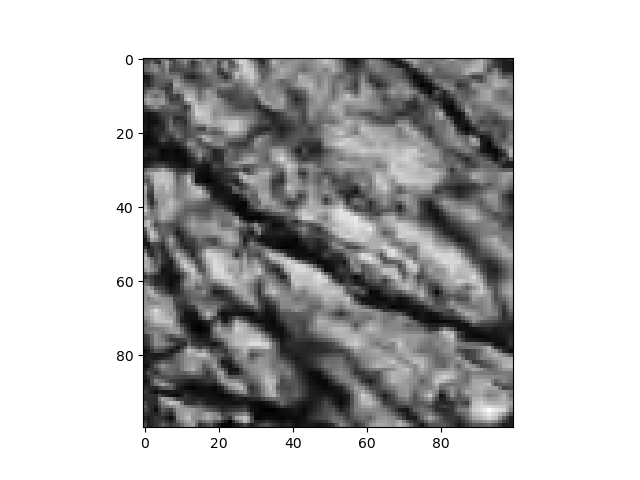

In [ ]:
# Load example myelin patch
# Originally from 'human_amyg/histology/MD847-My86-2021.12.14-09.16.22_MD847_1_0256_lossy.jp2'
# sliced at [32769:32869, 31189:31289]
Jpatch = plt.imread("images/myelin_patch.png")

# plot
fig = plt.figure()
plt.imshow(Jpatch, cmap="gray")

# Compute structure tensors and bin into circular ODFs (histograms on the unit circle)

In [ ]:
# Image patch to structure tensors
Jst = structure_tensor(Jpatch, derivative_sigma=6, tensor_sigma=6, id_minus_S=False)

# Structure tensors to angles
Jpatch_angles = angles(Jst)

# Angles to circular ODFs in Fourier coefficients 
codf_coeffs = directions.circular_odf(Jpatch_angles, shape_out=(2, 2))

# Circular ODFs to histogram representation
histogram, theta = directions.circular_odf_to_histogram(codf_coeffs)

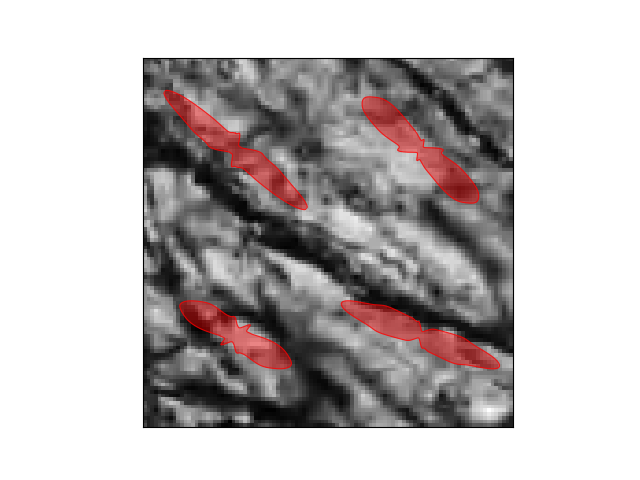

In [9]:
nrows, ncols = histogram.shape[:2]

theta_closed = np.append(theta, theta[0])

fig, ax = plt.subplots()
ax.imshow(Jpatch, cmap="gray")
ax.set_xticks([])
ax.set_yticks([])

# place a transparent polar axes over each grid cell of the image
for i in range(nrows):
    for j in range(ncols):
        pax = ax.inset_axes(
            [j / ncols, 1 - (i + 1) / nrows, 1 / ncols, 1 / nrows],
            projection="polar",
            zorder=2,
        )
        pax.patch.set_visible(False)
        r = np.append(histogram[i, j], histogram[i, j][0])
        # single filled polygon avoids the alpha build-up of overlapping bars
        pax.fill(theta_closed - np.pi / 2, r, color="red", alpha=0.4, linewidth=0)
        pax.plot(theta_closed - np.pi / 2, r, color="red", alpha=0.8, linewidth=0.8)
        pax.set_ylim(0, histogram.max())
        pax.set_xticks([])
        pax.set_yticks([])
        pax.grid(False)
        pax.set_frame_on(False)


# Get principal directions from 2D ODFS using finite difference method and k-means

In [10]:
# get primary orientations using k-means clustering on the circular ODFs
principal_dirs_FD = directions.circular_odf_directions(codf_coeffs, max_directions=2, relative_threshold=0.1)
principal_dirs_KM = periodic_kmeans(Jpatch_angles, k=2, period=np.pi, shape_out=(2, 2))

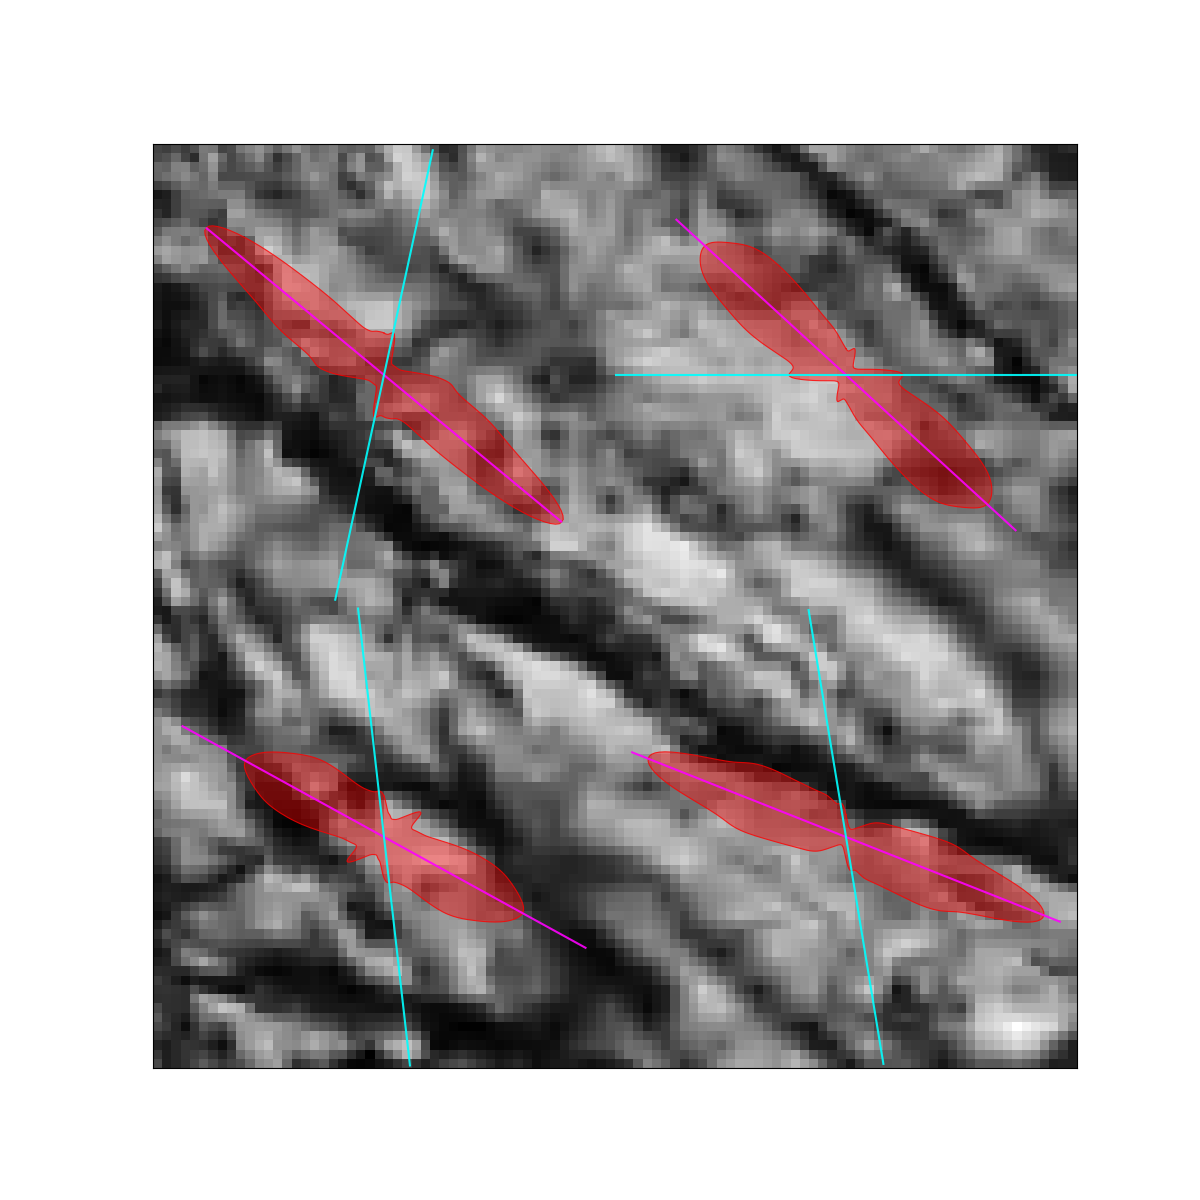

In [14]:
# plot the principal directions (angles on [-pi/2, pi/2]) over the ODFs and the image patch
nrows, ncols = histogram.shape[:2]
theta_closed = np.append(theta, theta[0])
rmax = histogram.max()
colors = ["magenta", "cyan", "yellow"]

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(Jpatch, cmap="gray")
ax.set_xticks([])
ax.set_yticks([])

for i in range(nrows):
    for j in range(ncols):
        pax = ax.inset_axes(
            [j / ncols, 1 - (i + 1) / nrows, 1 / ncols, 1 / nrows],
            projection="polar",
            zorder=2,
        )
        pax.patch.set_visible(False)
        r = np.append(histogram[i, j], histogram[i, j][0])
        # single filled polygon avoids the alpha build-up of overlapping bars
        pax.fill(theta_closed - np.pi / 2, r, color="red", alpha=0.4, linewidth=0)
        pax.plot(theta_closed - np.pi / 2, r, color="red", alpha=0.8, linewidth=0.8)

        for k, a in enumerate(principal_dirs_FD[i, j]):
            if not np.isfinite(a):
                continue
            # two radial spokes through the origin give an antipodal straight line
            pax.plot(
                [a - np.pi / 2, a - np.pi / 2, a + np.pi / 2],
                [rmax, 0, rmax],
                color=colors[k % len(colors)],
                linewidth=1.5,
                alpha=0.9,
            )

        pax.set_ylim(0, rmax)
        pax.set_xticks([])
        pax.set_yticks([])
        pax.grid(False)
        pax.set_frame_on(False)


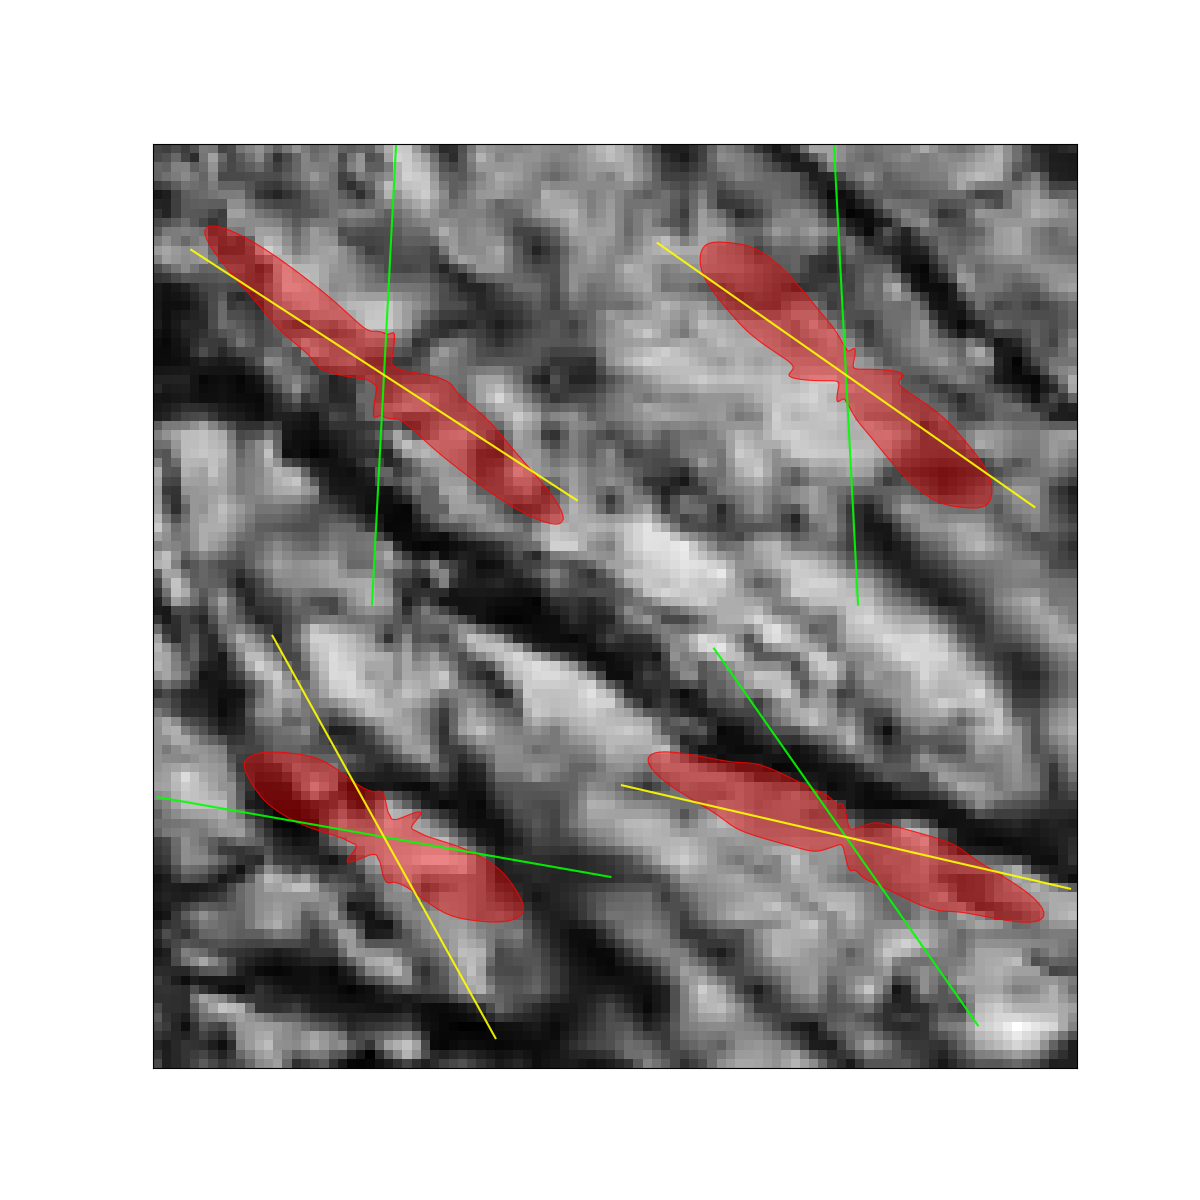

In [15]:
# plot the principal directions (angles on [-pi/2, pi/2]) over the ODFs and the image patch
nrows, ncols = histogram.shape[:2]
theta_closed = np.append(theta, theta[0])
rmax = histogram.max()
colors = ["lime", "yellow"]

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(Jpatch, cmap="gray")
ax.set_xticks([])
ax.set_yticks([])

for i in range(nrows):
    for j in range(ncols):
        pax = ax.inset_axes(
            [j / ncols, 1 - (i + 1) / nrows, 1 / ncols, 1 / nrows],
            projection="polar",
            zorder=2,
        )
        pax.patch.set_visible(False)
        r = np.append(histogram[i, j], histogram[i, j][0])
        # single filled polygon avoids the alpha build-up of overlapping bars
        pax.fill(theta_closed - np.pi / 2, r, color="red", alpha=0.4, linewidth=0)
        pax.plot(theta_closed - np.pi / 2, r, color="red", alpha=0.8, linewidth=0.8)

        for k, a in enumerate(principal_dirs_KM[i, j]):
            if not np.isfinite(a):
                continue
            # two radial spokes through the origin give an antipodal straight line
            pax.plot(
                [a - np.pi / 2, a - np.pi / 2, a + np.pi / 2],
                [rmax, 0, rmax],
                color=colors[k % len(colors)],
                linewidth=1.5,
                alpha=0.9,
            )

        pax.set_ylim(0, rmax)
        pax.set_xticks([])
        pax.set_yticks([])
        pax.grid(False)
        pax.set_frame_on(False)


# Orientations from 3D ODFs

In [86]:
# four synthetic 3D ODFs, each a mixture of two fiber populations lying in the xy plane
from dipy.data import get_sphere
from dipy.reconst.shm import sh_to_sf
from fibermetric.orientation_encoding import spherical_odf, spherical_odf_directions, apsym_kmeans

rng = np.random.default_rng(0)
true_angles = [(0.0, 90.0), (20.0, 80.0), (-30.0, 45.0), (10.0, 130.0)]
n_per_lobe = 400
angular_spread = np.deg2rad(30)


def sample_directions(pair):
    vectors = []
    for degrees in pair:
        azimuth = np.deg2rad(degrees) + rng.normal(0, angular_spread, n_per_lobe)
        # small out-of-plane jitter keeps the lobes 3D while staying near the xy plane
        out_of_plane = rng.normal(0, 0.05, n_per_lobe)
        vectors.append(np.stack((np.cos(azimuth), np.sin(azimuth), out_of_plane), axis=-1))
    vectors = np.concatenate(vectors)
    return vectors / np.linalg.norm(vectors, axis=-1, keepdims=True)


odf_samples = np.stack([sample_directions(pair) for pair in true_angles])
odf_coeffs = np.stack([spherical_odf(s, sh_order_max=8) for s in odf_samples])

# a finer sphere resolves the peaks more accurately than the default symmetric362
peak_sphere = get_sphere(name="repulsion724")
fd_dirs = spherical_odf_directions(
    odf_coeffs, max_directions=2, relative_threshold=0.3, sphere=peak_sphere
)
kmeans_dirs = np.stack([apsym_kmeans(s, k=2) for s in odf_samples])

in_plane = lambda v: np.degrees(np.arctan2(v[..., 1], v[..., 0])) % 180
for pair, fd, km in zip(true_angles, fd_dirs, kmeans_dirs):
    print(f"true {pair} | peaks {np.round(in_plane(fd), 1)} | kmeans {np.round(in_plane(km), 1)}")


true (0.0, 90.0) | peaks [ 95.2 174.5] | kmeans [175.2  85.2]
true (20.0, 80.0) | peaks [62.5  nan] | kmeans [ 7.2 77.1]
true (-30.0, 45.0) | peaks [ 31.4 158.2] | kmeans [147.6  47.7]
true (10.0, 130.0) | peaks [166.7   nan] | kmeans [131.5  19.7]


## Get principal directions from 3D ODFS with finite differences method and K-means

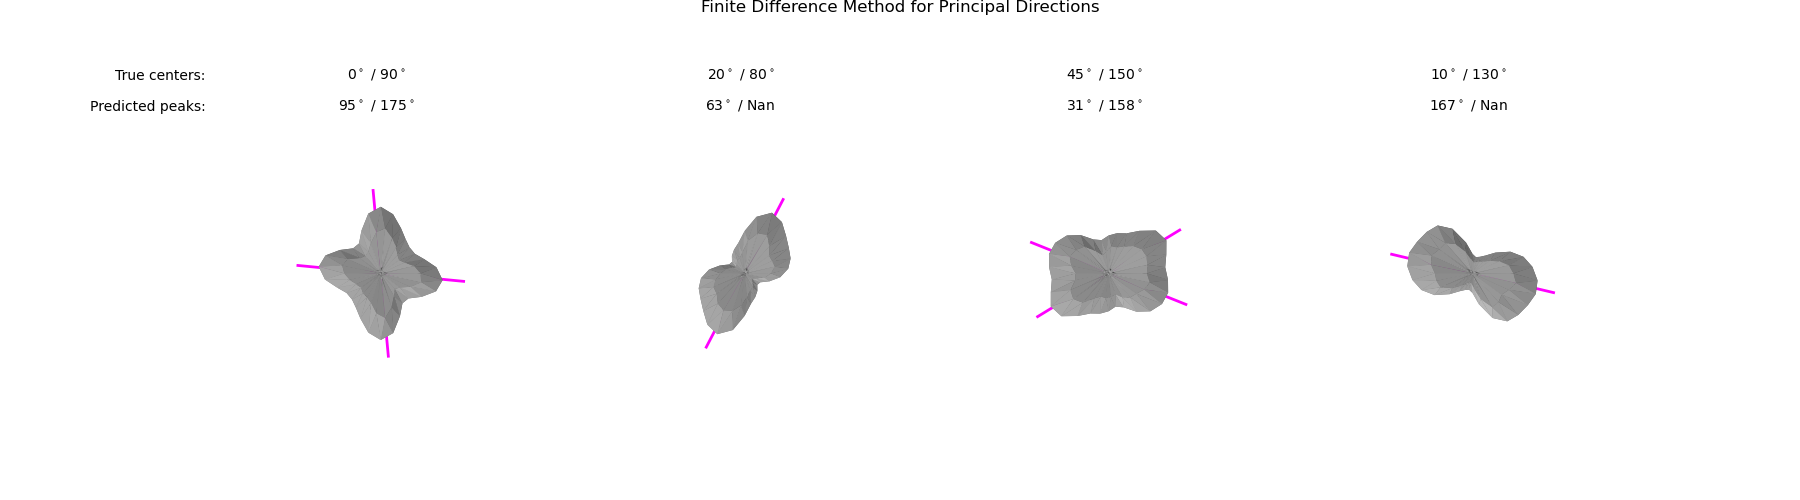

In [87]:
# ODFs with the principal directions found by spherical_odf_directions
glyph_sphere = get_sphere(name="symmetric362")


def plot_odf_with_directions(ax, coefficients, dirs, color):
    sf = np.clip(
        sh_to_sf(coefficients, glyph_sphere, sh_order_max=8, basis_type="descoteaux07", legacy=False),
        0,
        None,
    )
    points = glyph_sphere.vertices * (sf / sf.max())[:, None]
    ax.plot_trisurf(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        triangles=glyph_sphere.faces,
        color="0.75",
        linewidth=0,
        antialiased=True,
    )

    for vector in dirs:
        if not np.all(np.isfinite(vector)):
            continue
        # a segment through the origin renders the antipodally symmetric axis
        segment = np.stack((-1.25 * vector, 1.25 * vector))
        ax.plot(segment[:, 0], segment[:, 1], segment[:, 2], color=color, linewidth=2.0)

    for set_limit in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        set_limit(-1.3, 1.3)
    ax.set_box_aspect((1, 1, 1))
    # look down z so the in-plane lobes and axes are both visible
    ax.view_init(elev=90, azim=-90)
    ax.set_axis_off()


def format_angles(values):
    # fold to [0, 180) so true and predicted axes are directly comparable
    folded = np.sort(np.asarray(values, dtype=float) % 180)
    return " / ".join("Nan" if not np.isfinite(a) else f"{a:.0f}$^\\circ$" for a in folded)


def label_panel(ax, true_pair, predicted, first):
    for row, (label, values) in enumerate((("True centers: ", true_pair), ("Predicted peaks: ", predicted))):
        y = 1.14 - 0.10 * row
        # Axes3D.text needs a z coordinate, so text2D places annotations in axes coordinates
        ax.text2D(0.5, y, format_angles(values), transform=ax.transAxes, ha="center", va="bottom")
        if first:
            ax.text2D(-0.05, y, label, transform=ax.transAxes, ha="right", va="bottom")


plt.close("all")
fig = plt.figure(figsize=(18, 5))
for index, (coefficients, dirs) in enumerate(zip(odf_coeffs, fd_dirs)):
    ax = fig.add_subplot(1, 4, index + 1, projection="3d")
    plot_odf_with_directions(ax, coefficients, dirs, "magenta")
    label_panel(ax, true_angles[index], in_plane(dirs), index == 0)
fig.suptitle("Finite Difference Method for Principal Directions", y=1.0)
fig.subplots_adjust(top=0.78)


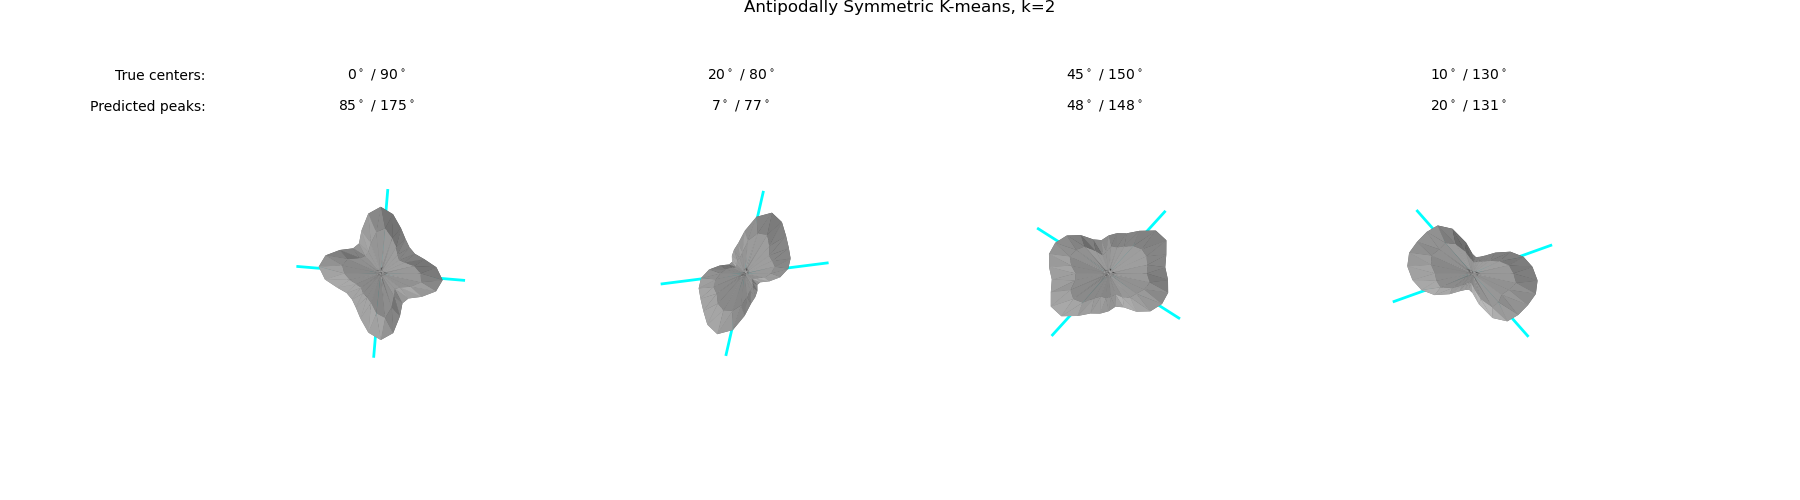

In [88]:
# the same ODFs with the two apsym_kmeans mean directions
plt.close("all")
fig = plt.figure(figsize=(18, 5))
for index, (coefficients, dirs) in enumerate(zip(odf_coeffs, kmeans_dirs)):
    ax = fig.add_subplot(1, 4, index + 1, projection="3d")
    plot_odf_with_directions(ax, coefficients, dirs, "cyan")
    label_panel(ax, true_angles[index], in_plane(dirs), index == 0)
fig.suptitle("Antipodally Symmetric K-means, k=2", y=1.0)
fig.subplots_adjust(top=0.78)


# Transform 3D ODFs to 2D ODFs

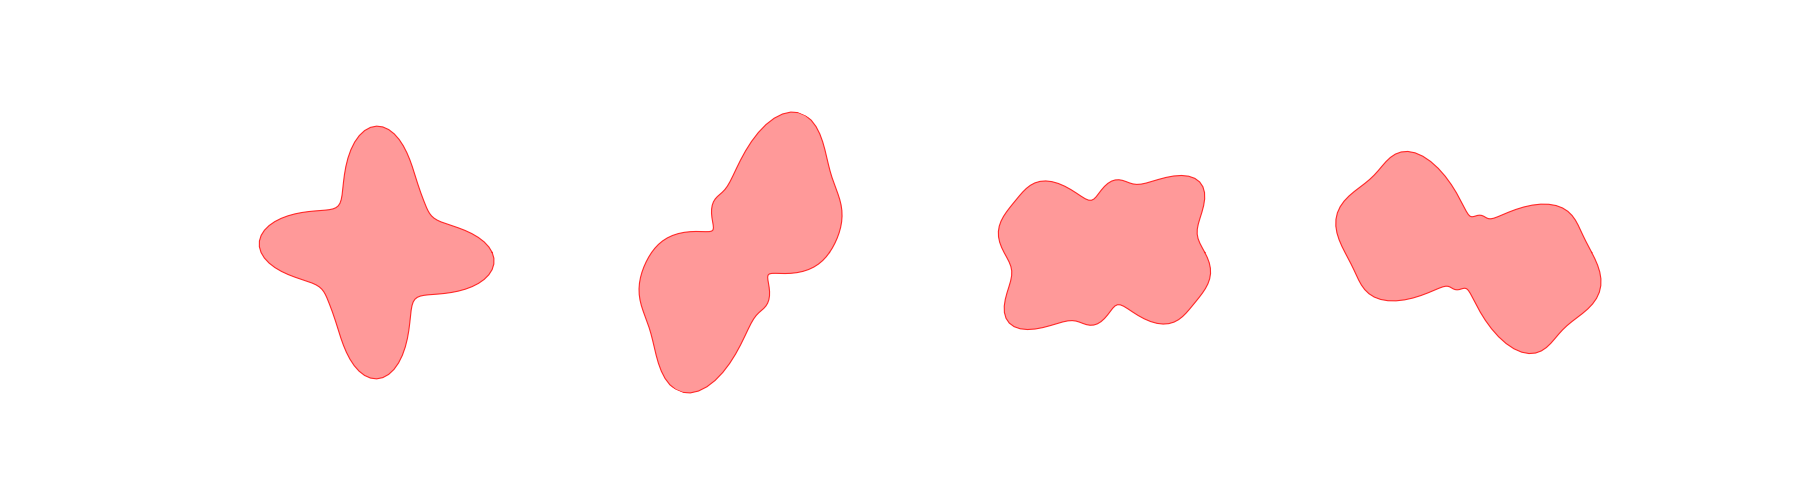

In [82]:
# the same ODFs collapsed to circular functions by integrating over polar angle
from fibermetric.transform import sh_to_cf

circular, azimuth = sh_to_cf(odf_coeffs, ndir=100, nbins=128, sh_order_max=8)
azimuth_closed = np.append(azimuth, azimuth[0])

plt.close("all")
fig = plt.figure(figsize=(18, 5))
for index, values in enumerate(circular):
    ax = fig.add_subplot(1, 4, index + 1, projection="polar")
    r = np.append(values, values[0])
    ax.fill(azimuth_closed, r, color="red", alpha=0.4, linewidth=0)
    ax.plot(azimuth_closed, r, color="red", alpha=0.8, linewidth=0.8)
    ax.set_ylim(0, circular.max())
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.set_frame_on(False)


# Compute distances on ODFs

# 3D ODFs

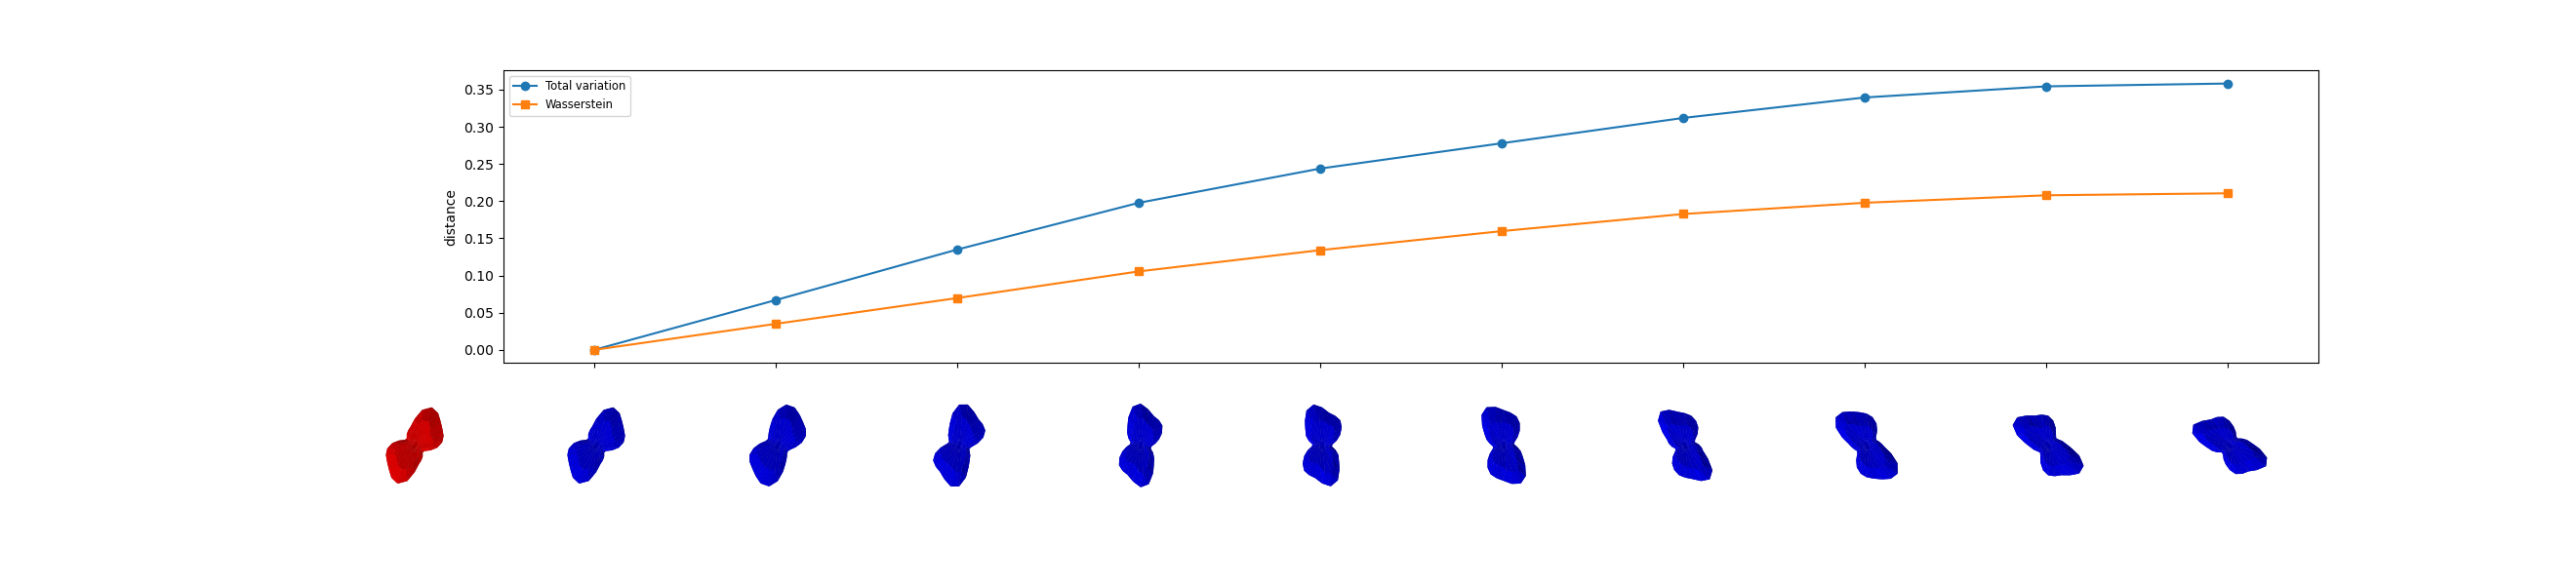

In [95]:
example_odf_3d = odf_coeffs[1]
example_odf_2d, azimuth = sh_to_cf(example_odf_3d, ndir=100, nbins=128, sh_order_max=8)
azimuth_closed = np.append(azimuth, azimuth[0])

# Plot 3D distances using both total variation and Wasserstein disinstance
rotations = list(range(0, 100, 10))


def rotate_z(vectors, degrees):
    angle = np.deg2rad(degrees)
    rotation = np.array([
        [np.cos(angle), -np.sin(angle), 0.0],
        [np.sin(angle), np.cos(angle), 0.0],
        [0.0, 0.0, 1.0],
    ])
    return vectors @ rotation.T


rotated_coeffs = [spherical_odf(rotate_z(odf_samples[1], d), sh_order_max=8) for d in rotations]
tv_dists_3d = [odf.spherical_odf_distance(example_odf_3d, c, metric="total_variation") for c in rotated_coeffs]
# 1/(pi/2) normalizes the Wasserstein distance to [0, 1] for antipodally symmetric spherical distributions
ws_dists_3d = [odf.spherical_odf_distance(example_odf_3d, c, metric="wasserstein") / (np.pi / 2) for c in rotated_coeffs]


def plot_odf_glyph(ax, coefficients, color):
    sf = np.clip(
        sh_to_sf(coefficients, glyph_sphere, sh_order_max=8, basis_type="descoteaux07", legacy=False),
        0,
        None,
    )
    points = glyph_sphere.vertices * (sf / sf.max())[:, None]
    ax.plot_trisurf(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        triangles=glyph_sphere.faces,
        color=color,
        linewidth=0,
        antialiased=True,
    )
    for set_limit in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        set_limit(-1.0, 1.0)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=90, azim=-90)
    ax.set_axis_off()


ncols = 1 + len(rotated_coeffs)
plt.close("all")
fig = plt.figure(figsize=(2.4 * ncols, 6.0))
# wspace=0 keeps each glyph centered on its matching x-tick
gs = fig.add_gridspec(2, ncols, height_ratios=[2, 1], hspace=0.05, wspace=0)

# distance curves span only the columns holding the rotated ODFs
dist_ax = fig.add_subplot(gs[0, 1:])
dist_ax.plot(rotations, tv_dists_3d, marker="o", label="Total variation")
dist_ax.plot(rotations, ws_dists_3d, marker="s", label="Wasserstein")
dist_ax.set_xlim(rotations[0] - 5, rotations[-1] + 5)
dist_ax.set_xticks(rotations)
dist_ax.set_xticklabels([])
dist_ax.set_ylabel("distance")
dist_ax.legend(fontsize="small")

plot_odf_glyph(fig.add_subplot(gs[1, 0], projection="3d"), example_odf_3d, "red")
for col, coefficients in enumerate(rotated_coeffs, start=1):
    plot_odf_glyph(fig.add_subplot(gs[1, col], projection="3d"), coefficients, "blue")


# 2D ODFs

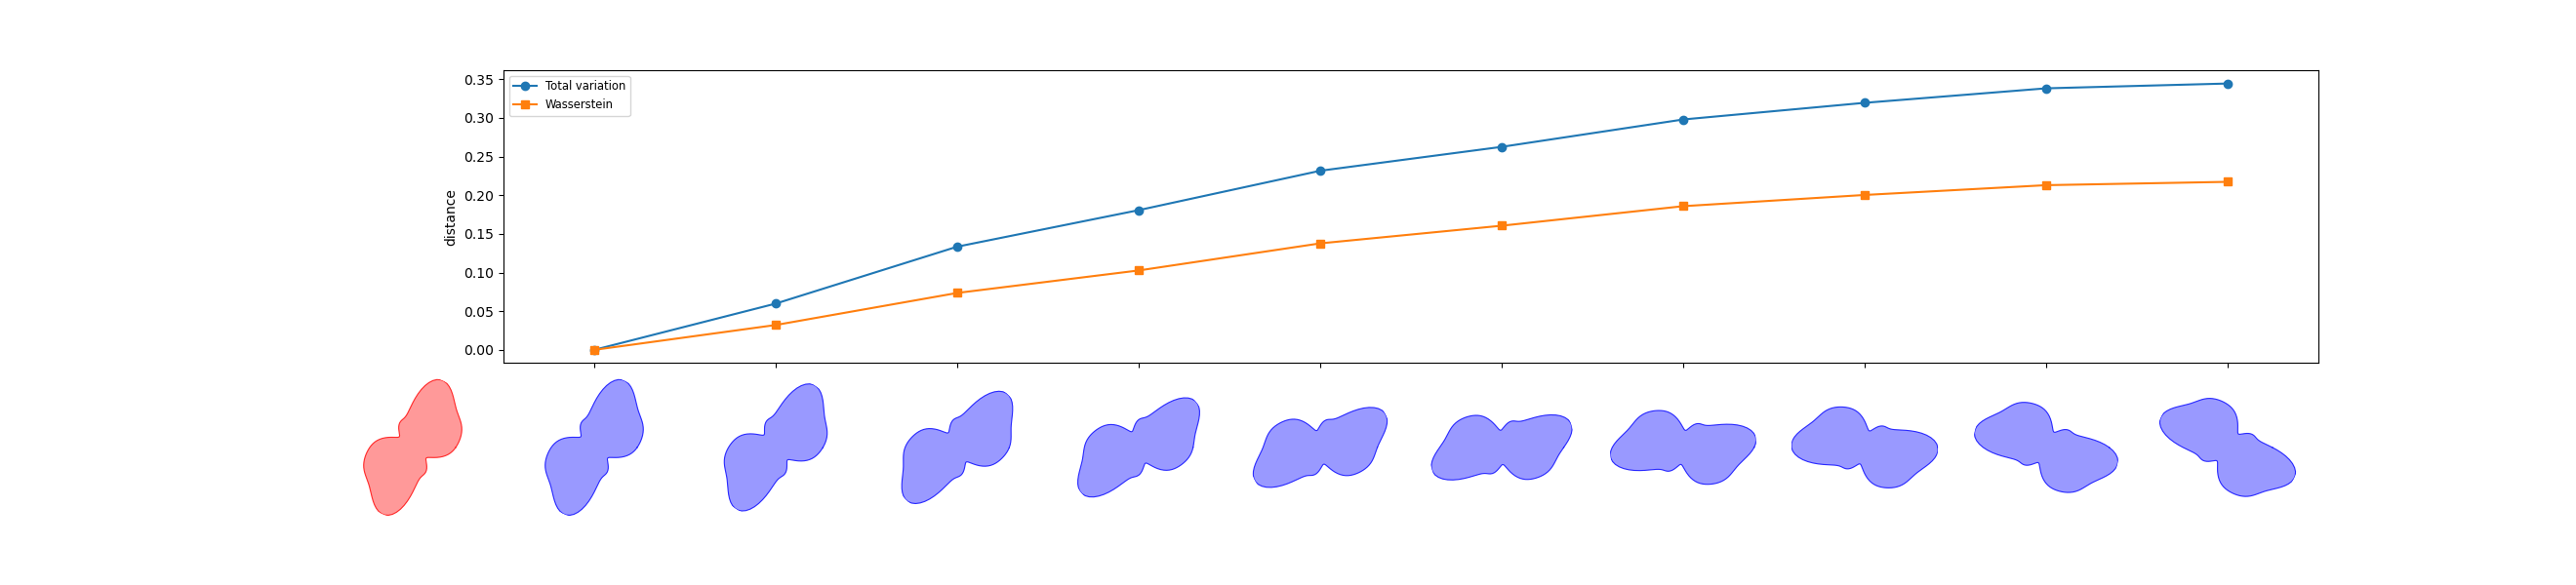

In [96]:
hist00 = example_odf_2d
nbins = len(hist00)
shifts = list(range(0, 100, 10))
hists = [np.concatenate((hist00[int(t*nbins/360):], hist00[:int(t*nbins/360)])) for t in shifts]
# the distance functions take Fourier coefficients, not histograms
coeffs00 = np.fft.rfft(hist00)
coeffs = [np.fft.rfft(h) for h in hists]
tv_dists = [odf.circular_odf_distance(coeffs00, c, metric='total_variation') for c in coeffs]
ws_dists = [odf.circular_odf_distance(coeffs00, c, metric='wasserstein') / (np.pi/2) for c in coeffs] # 1/(pi/2) normalizes the Wasserstein distance to [0, 1] for circular distributions


def plot_odf(ax, values, color):
    ax.patch.set_visible(False)
    r = np.append(values, values[0])
    ax.fill(azimuth_closed, r, color=color, alpha=0.4, linewidth=0)
    ax.plot(azimuth_closed, r, color=color, alpha=0.8, linewidth=0.8)
    ax.set_ylim(0, max(hist00.max(), values.max()))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.set_frame_on(False)


ncols = 1 + len(hists)
plt.close("all")
fig = plt.figure(figsize=(2.4 * ncols, 6.0))
# wspace=0 keeps each ODF centered on its matching x-tick
gs = fig.add_gridspec(2, ncols, height_ratios=[2, 1], hspace=0.05, wspace=0)

# distance curves span only the columns holding the shifted ODFs
dist_ax = fig.add_subplot(gs[0, 1:])
dist_ax.plot(shifts, tv_dists, marker="o", label="Total variation")
dist_ax.plot(shifts, ws_dists, marker="s", label="Wasserstein")
dist_ax.set_xlim(shifts[0] - 5, shifts[-1] + 5)
dist_ax.set_xticks(shifts)
dist_ax.set_xticklabels([])
dist_ax.set_ylabel("distance")
dist_ax.legend(fontsize="small")

plot_odf(fig.add_subplot(gs[1, 0], projection="polar"), hist00, "red")
for col, values in enumerate(hists, start=1):
    plot_odf(fig.add_subplot(gs[1, col], projection="polar"), values, "blue")


# Compute distances on 3D tensors

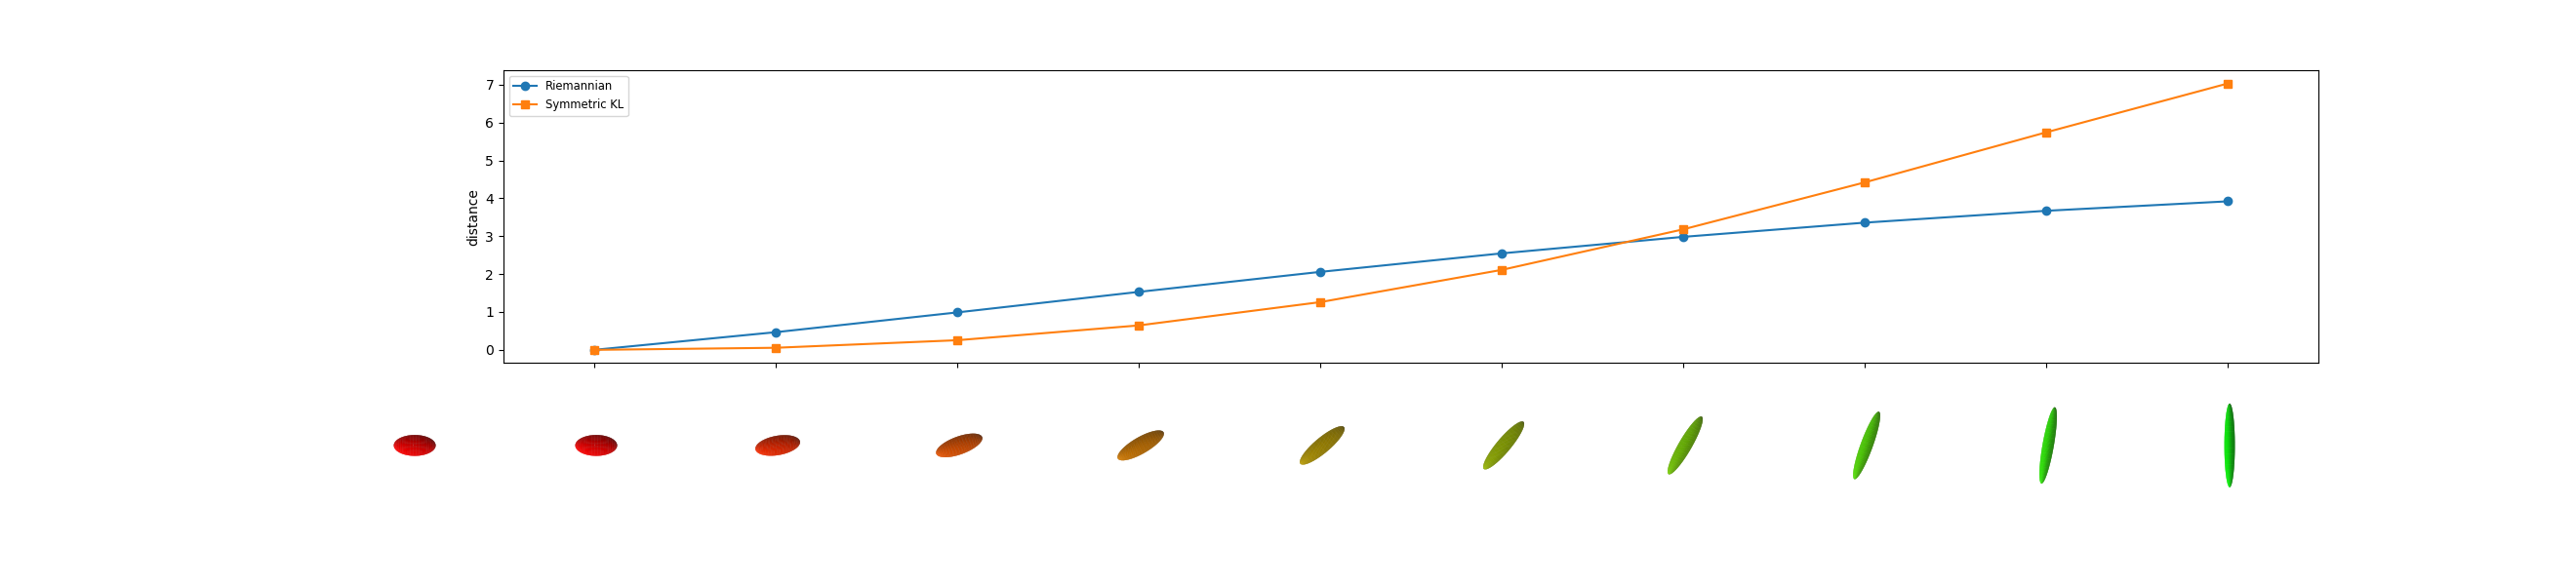

In [97]:
# Tensor difference: one reference tensor and increasingly deformed copies
from fibermetric.difference_measures import riemannian_tensor_distance, symmetric_kl_tensor_distance

tensor0 = np.diag([1.0, 0.25, 0.25])
strengths = np.linspace(0.0, 1.0, 10)
max_angle = np.pi / 2
max_stretch = 2.0


def in_plane_deformation(strength):
    """Rotation and volume-preserving stretch within the x-y plane."""
    angle = strength * max_angle
    k = max_stretch ** strength
    rotation = np.array([
        [np.cos(angle), -np.sin(angle), 0.0],
        [np.sin(angle), np.cos(angle), 0.0],
        [0.0, 0.0, 1.0],
    ])
    return rotation @ np.diag([k, 1 / k, 1.0])


deformed = []
for s in strengths:
    f = in_plane_deformation(s)
    deformed.append(f @ tensor0 @ f.T)

riem_dists = [riemannian_tensor_distance(tensor0, t) for t in deformed]
skl_dists = [symmetric_kl_tensor_distance(tensor0, t) for t in deformed]

u, v = np.mgrid[0:2*np.pi:48j, 0:np.pi:24j]
unit_sphere = np.stack((np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v))).reshape(3, -1)
rmax = max(np.sqrt(np.linalg.eigvalsh(t).max()) for t in [tensor0] + deformed)


def plot_single_tensor(ax, tensor):
    evals, evecs = np.linalg.eigh(tensor)
    points = evecs @ (np.sqrt(np.clip(evals, 0, None))[:, None] * unit_sphere)
    gx, gy, gz = points.reshape(3, *u.shape)
    ax.plot_surface(gx, gy, gz, color=np.abs(evecs[:, -1]), linewidth=0, antialiased=True)
    for axis in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        axis(-rmax, rmax)
    ax.set_box_aspect((1, 1, 1))
    # look down the z axis so the in-plane rotation and stretch are visible
    ax.view_init(elev=90, azim=-90)
    ax.set_axis_off()


plt.close("all")
ncols = 1 + len(deformed)
fig = plt.figure(figsize=(2.4 * ncols, 6.0))
# wspace=0 keeps each glyph centered on its matching x-tick
gs = fig.add_gridspec(2, ncols, height_ratios=[2, 1], hspace=0.05, wspace=0)

dist_ax = fig.add_subplot(gs[0, 1:])
dist_ax.plot(strengths, riem_dists, marker="o", label="Riemannian")
dist_ax.plot(strengths, skl_dists, marker="s", label="Symmetric KL")
half_step = 0.5 * (strengths[1] - strengths[0])
dist_ax.set_xlim(strengths[0] - half_step, strengths[-1] + half_step)
dist_ax.set_xticks(strengths)
dist_ax.set_xticklabels([])
dist_ax.set_ylabel("distance")
dist_ax.legend(fontsize="small")

plot_single_tensor(fig.add_subplot(gs[1, 0], projection="3d"), tensor0)
for col, tensor in enumerate(deformed, start=1):
    plot_single_tensor(fig.add_subplot(gs[1, col], projection="3d"), tensor)


# Deform DTI

## Construct synthetic DTI example

In [61]:
dti_patch = np.broadcast_to(np.diag([0.25, 1.0, 0.25]), (6, 6, 3, 3))
dti_patch.shape


(6, 6, 3, 3)

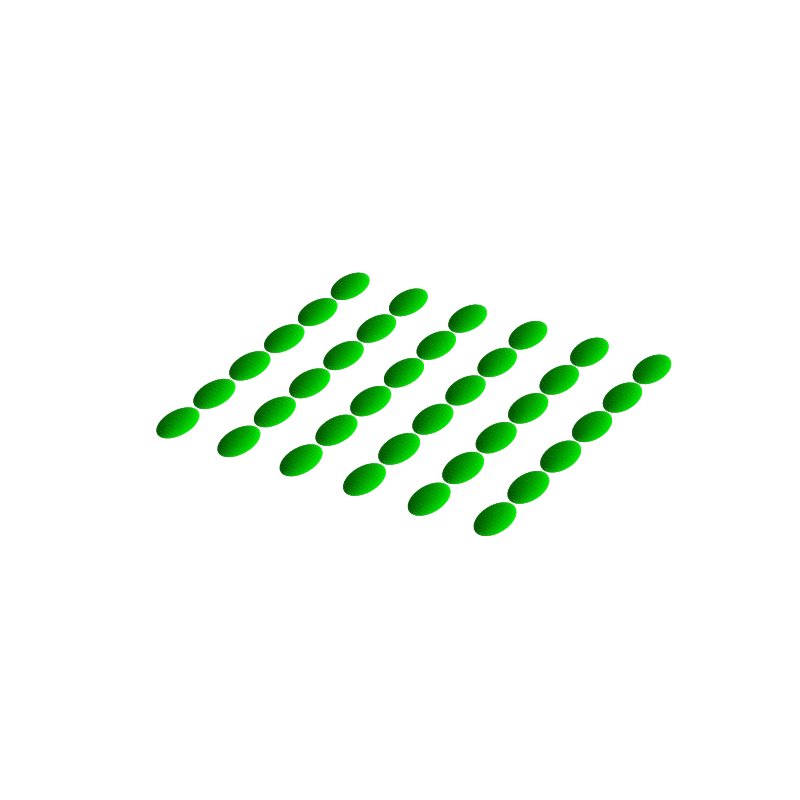

In [63]:
# visualize the DTI patch as a grid of tensor ellipsoids
u, v = np.mgrid[0:2*np.pi:32j, 0:np.pi:16j]
unit_sphere = np.stack((np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v))).reshape(3, -1)

evals, evecs = np.linalg.eigh(dti_patch)
evals = np.clip(evals, 0, None)
# uniform glyph size so neighboring ellipsoids do not overlap
scale = 0.45 / np.sqrt(evals.max())

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
for i in range(dti_patch.shape[0]):
    for j in range(dti_patch.shape[1]):
        radii = scale * np.sqrt(evals[i, j])
        points = evecs[i, j] @ (radii[:, None] * unit_sphere)
        gx, gy, gz = points.reshape(3, *u.shape)
        color = np.abs(evecs[i, j][:, -1])  # direction-encoded color from the principal axis
        ax.plot_surface(gx + i, gy + j, gz, color=color, linewidth=0, antialiased=True)

ax.set_box_aspect((dti_patch.shape[0], dti_patch.shape[1], 1))
ax.set_zlim(-1, 1)
ax.set_axis_off()


## Construct synthetic non-linear deformation

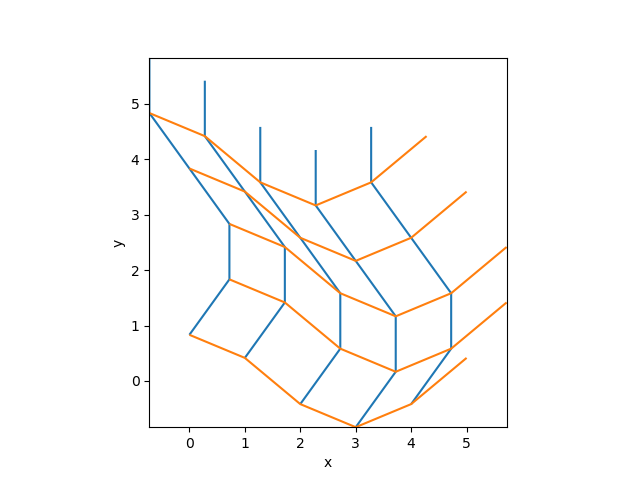

In [ ]:
# make an example non-linear deformation field
# Make it a simple sinusoidal deformation

# sample the deformation on a padded grid so the transform never reads out of bounds
margin = 6
padded_shape = tuple(s + 2 * margin for s in dti_patch.shape[:2])
# padded indices expressed in the coordinates of the original patch
coords_pad = np.indices(padded_shape) - margin
interior = (
    slice(margin, margin + dti_patch.shape[0]),
    slice(margin, margin + dti_patch.shape[1]),
)

x_def_pad = coords_pad[1] + np.sin(2 * np.pi * coords_pad[0] / 6)/1.2
y_def_pad = coords_pad[0] + np.cos(2 * np.pi * coords_pad[1] / 6)/1.2

coords = coords_pad[(slice(None),) + interior]
x_def = x_def_pad[interior]
y_def = y_def_pad[interior]

# plot the coordinate deformation
plt.close('all')
fig, ax = plt.subplots()

# Contours of constant original x- and y-coordinates in the deformed grid
x_levels = np.arange(coords[1].min(), coords[1].max() + 1)
y_levels = np.arange(coords[0].min(), coords[0].max() + 1)

ax.contour(x_def, y_def, coords[1], levels=x_levels, colors="tab:blue")
ax.contour(x_def, y_def, coords[0], levels=y_levels, colors="tab:orange")

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

# The displacement has to be 3D for the DTI patch, so we can add a zero z-component to the displacement field.
# Component i is the displacement along array axis i: axis 0 is y (rows), axis 1 is x (columns).
z_def = np.zeros_like(x_def_pad)
displacement = np.stack((y_def_pad - coords_pad[0], x_def_pad - coords_pad[1], z_def), axis=0)  # shape (3, H, W)


## Apply the deformation to the DTI

In [64]:
# apply the deformation to the DTI patch

# pad the tensor field so samples pulled from outside the patch are real tensors instead of zeros
dti_padded = np.pad(dti_patch, ((margin, margin), (margin, margin), (0, 0), (0, 0)), mode="edge")

# the transform expects a 3D volume, so stack identical slices along z and keep the middle one
nz = 3
dti_volume = np.repeat(dti_padded[:, :, None], nz, axis=2)
displacement3d = np.zeros((3,) + dti_volume.shape[:3])
# expand the in-plane displacement across the synthetic z dimension
displacement3d[:2] = displacement[:2, :, :, None]

transformed_padded = transform_tensors_with_displacement(dti_volume, displacement3d)[:, :, nz // 2]
transformed_dti_patch = transformed_padded[interior]
print(transformed_dti_patch.shape)


(6, 6, 3, 3)


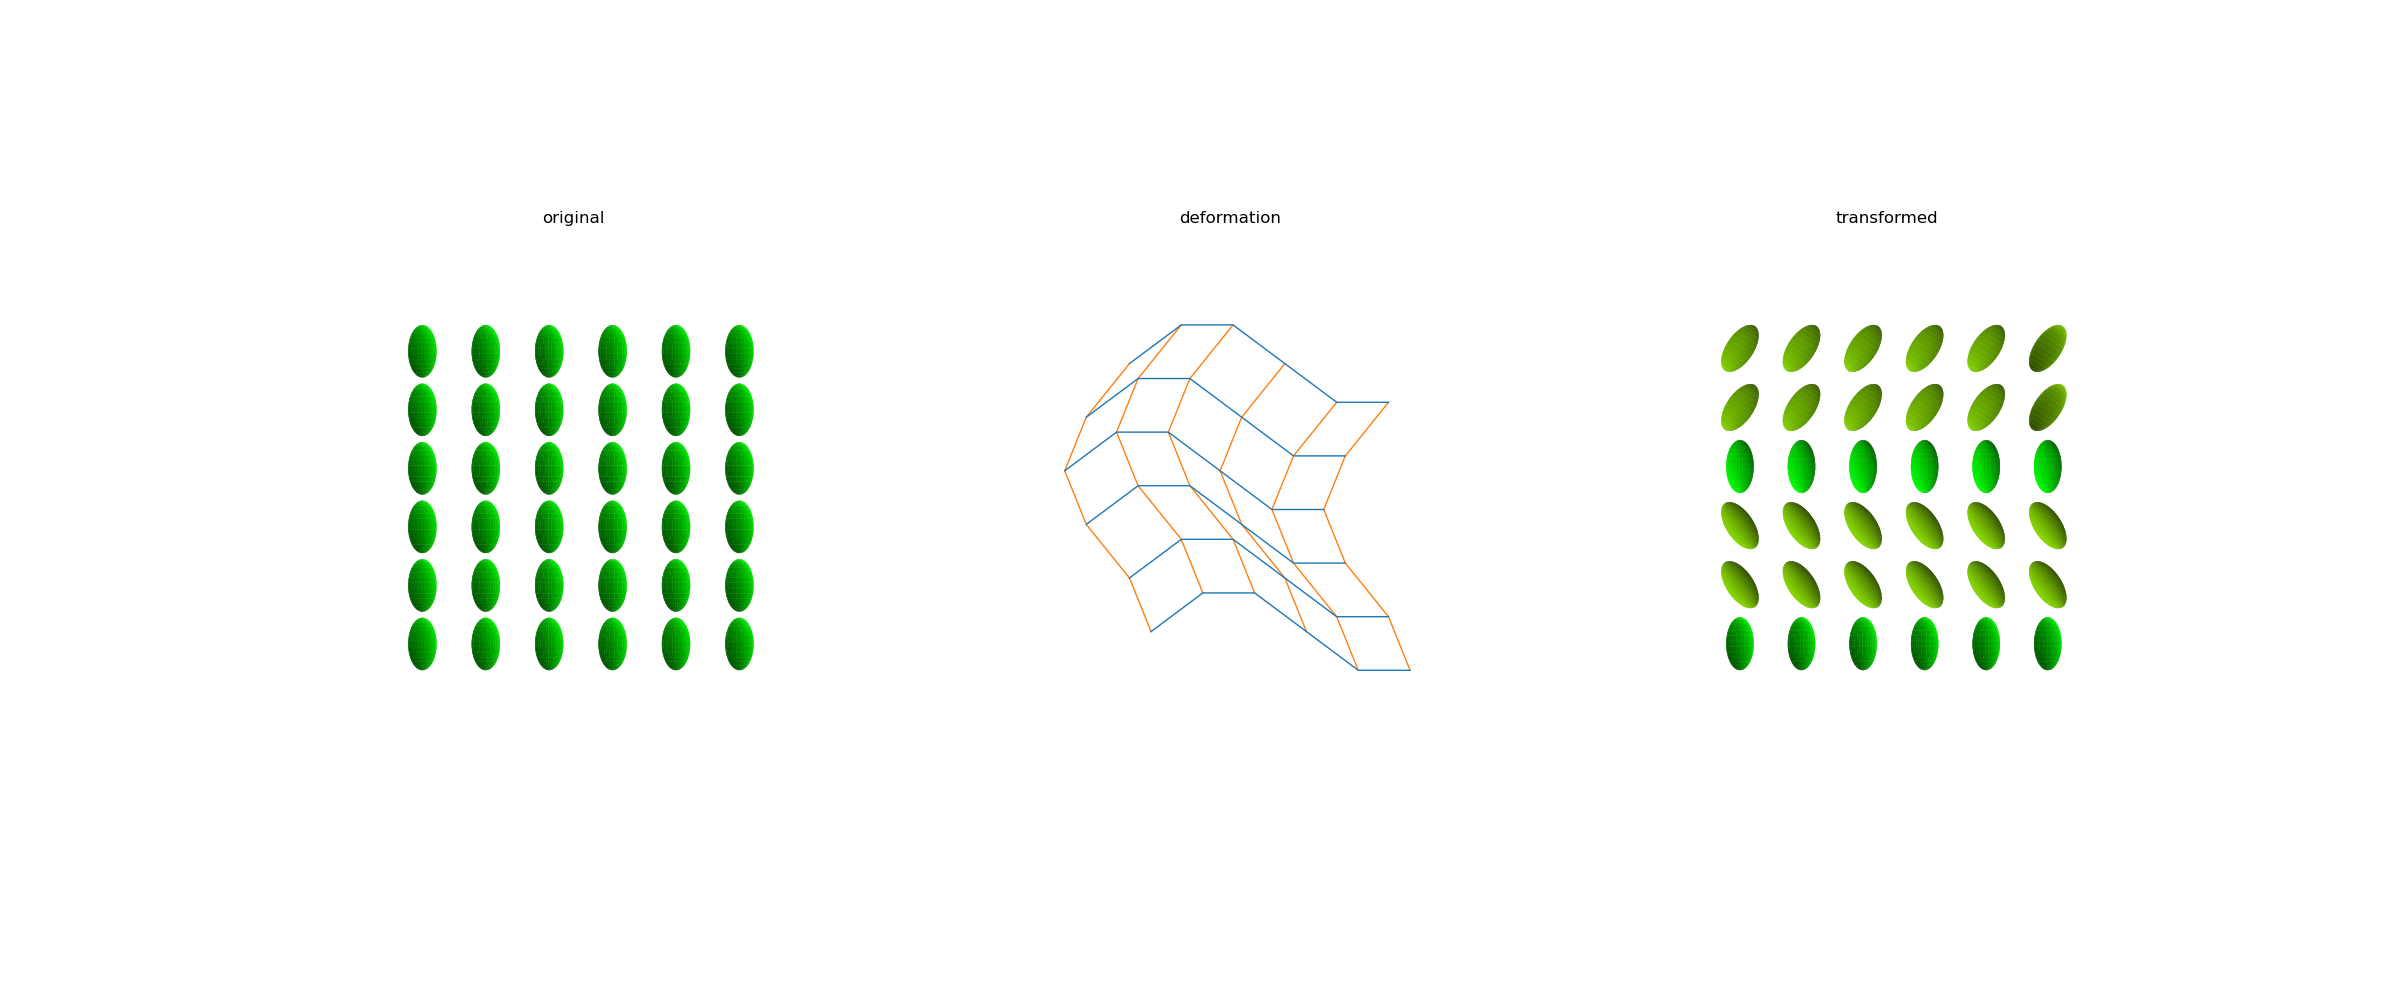

In [65]:
# original tensors, the deformed grid, and the transformed tensors side by side
u, v = np.mgrid[0:2*np.pi:32j, 0:np.pi:16j]
unit_sphere = np.stack((np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v))).reshape(3, -1)


def set_patch_view(ax, shape, title):
    ax.set_box_aspect((shape[0], shape[1], 1))
    ax.set_zlim(-1, 1)
    ax.view_init(elev=90, azim=-90)
    ax.set_axis_off()
    ax.set_title(title)


def plot_tensors(ax, tensors, title):
    evals, evecs = np.linalg.eigh(tensors)
    evals = np.clip(evals, 0, None)
    # uniform glyph size so neighboring ellipsoids do not overlap
    scale = 0.45 / np.sqrt(evals.max())

    for i in range(tensors.shape[0]):
        for j in range(tensors.shape[1]):
            radii = scale * np.sqrt(evals[i, j])
            points = evecs[i, j] @ (radii[:, None] * unit_sphere)
            gx, gy, gz = points.reshape(3, *u.shape)
            color = np.abs(evecs[i, j][:, -1])  # direction-encoded color from the principal axis
            ax.plot_surface(gx + i, gy + j, gz, color=color, linewidth=0, antialiased=True)

    set_patch_view(ax, tensors.shape[:2], title)


def plot_grid(ax, grid_x, grid_y, title):
    # same axes type and view as the glyph panels so the orientation matches exactly
    for i in range(grid_x.shape[0]):
        ax.plot(grid_y[i, :], grid_x[i, :], zs=0.0, color="tab:orange", linewidth=1.0)
    for j in range(grid_x.shape[1]):
        ax.plot(grid_y[:, j], grid_x[:, j], zs=0.0, color="tab:blue", linewidth=1.0)

    set_patch_view(ax, grid_x.shape, title)


plt.close("all")
fig = plt.figure(figsize=(24, 10))

x_def_pad_inv = 2*coords_pad[1] - x_def_pad
y_def_pad_inv = 2*coords_pad[0] - y_def_pad
x_def_inv = x_def_pad_inv[interior]
y_def_inv = y_def_pad_inv[interior]
plot_tensors(fig.add_subplot(1, 3, 1, projection="3d"), dti_patch, "original")
plot_grid(fig.add_subplot(1, 3, 2, projection="3d"), x_def, y_def, "deformation")
# plot_grid(fig.add_subplot(1, 3, 2, projection="3d"), x_def_inv, y_def_inv, "deformation")
plot_tensors(fig.add_subplot(1, 3, 3, projection="3d"), transformed_dti_patch, "transformed")


# Deform 3D ODFs

## Construct synthetic ODF image

In [48]:
# build a 6x6 patch of symmetric spherical harmonic ODFs
from dipy.data import get_sphere
from dipy.reconst.shm import sf_to_sh, sh_to_sf
from fibermetric.transform import transform_sh_img

sh_order_max = 8
sphere = get_sphere(name="symmetric362")

# single-fiber ODF peaked along y, matching the principal direction of dti_patch
fiber_dir = np.array([0.0, 1.0, 0.0])
sf0 = np.abs(sphere.vertices @ fiber_dir) ** 16
sf0 /= sf0.sum()
sh0 = sf_to_sh(sf0, sphere, sh_order_max=sh_order_max, basis_type="descoteaux07", legacy=False)

sh_patch = np.broadcast_to(sh0, (6, 6) + sh0.shape).copy()
print(sh_patch.shape)


(6, 6, 45)


# Apply the same deformation

In [49]:
# apply the same deformation to the ODF patch

# pad the SH field so samples pulled from outside the patch are real ODFs instead of zeros
sh_padded = np.pad(sh_patch, ((margin, margin), (margin, margin), (0, 0)), mode="edge")

# the transform expects a 3D volume, so stack identical slices along z and keep the middle one
sh_volume = np.repeat(sh_padded[:, :, None], nz, axis=2)

transformed_sh_padded = transform_sh_img(sh_volume, displacement3d)[:, :, nz // 2]
transformed_sh_patch = transformed_sh_padded[interior]
print(transformed_sh_patch.shape)


(6, 6, 45)


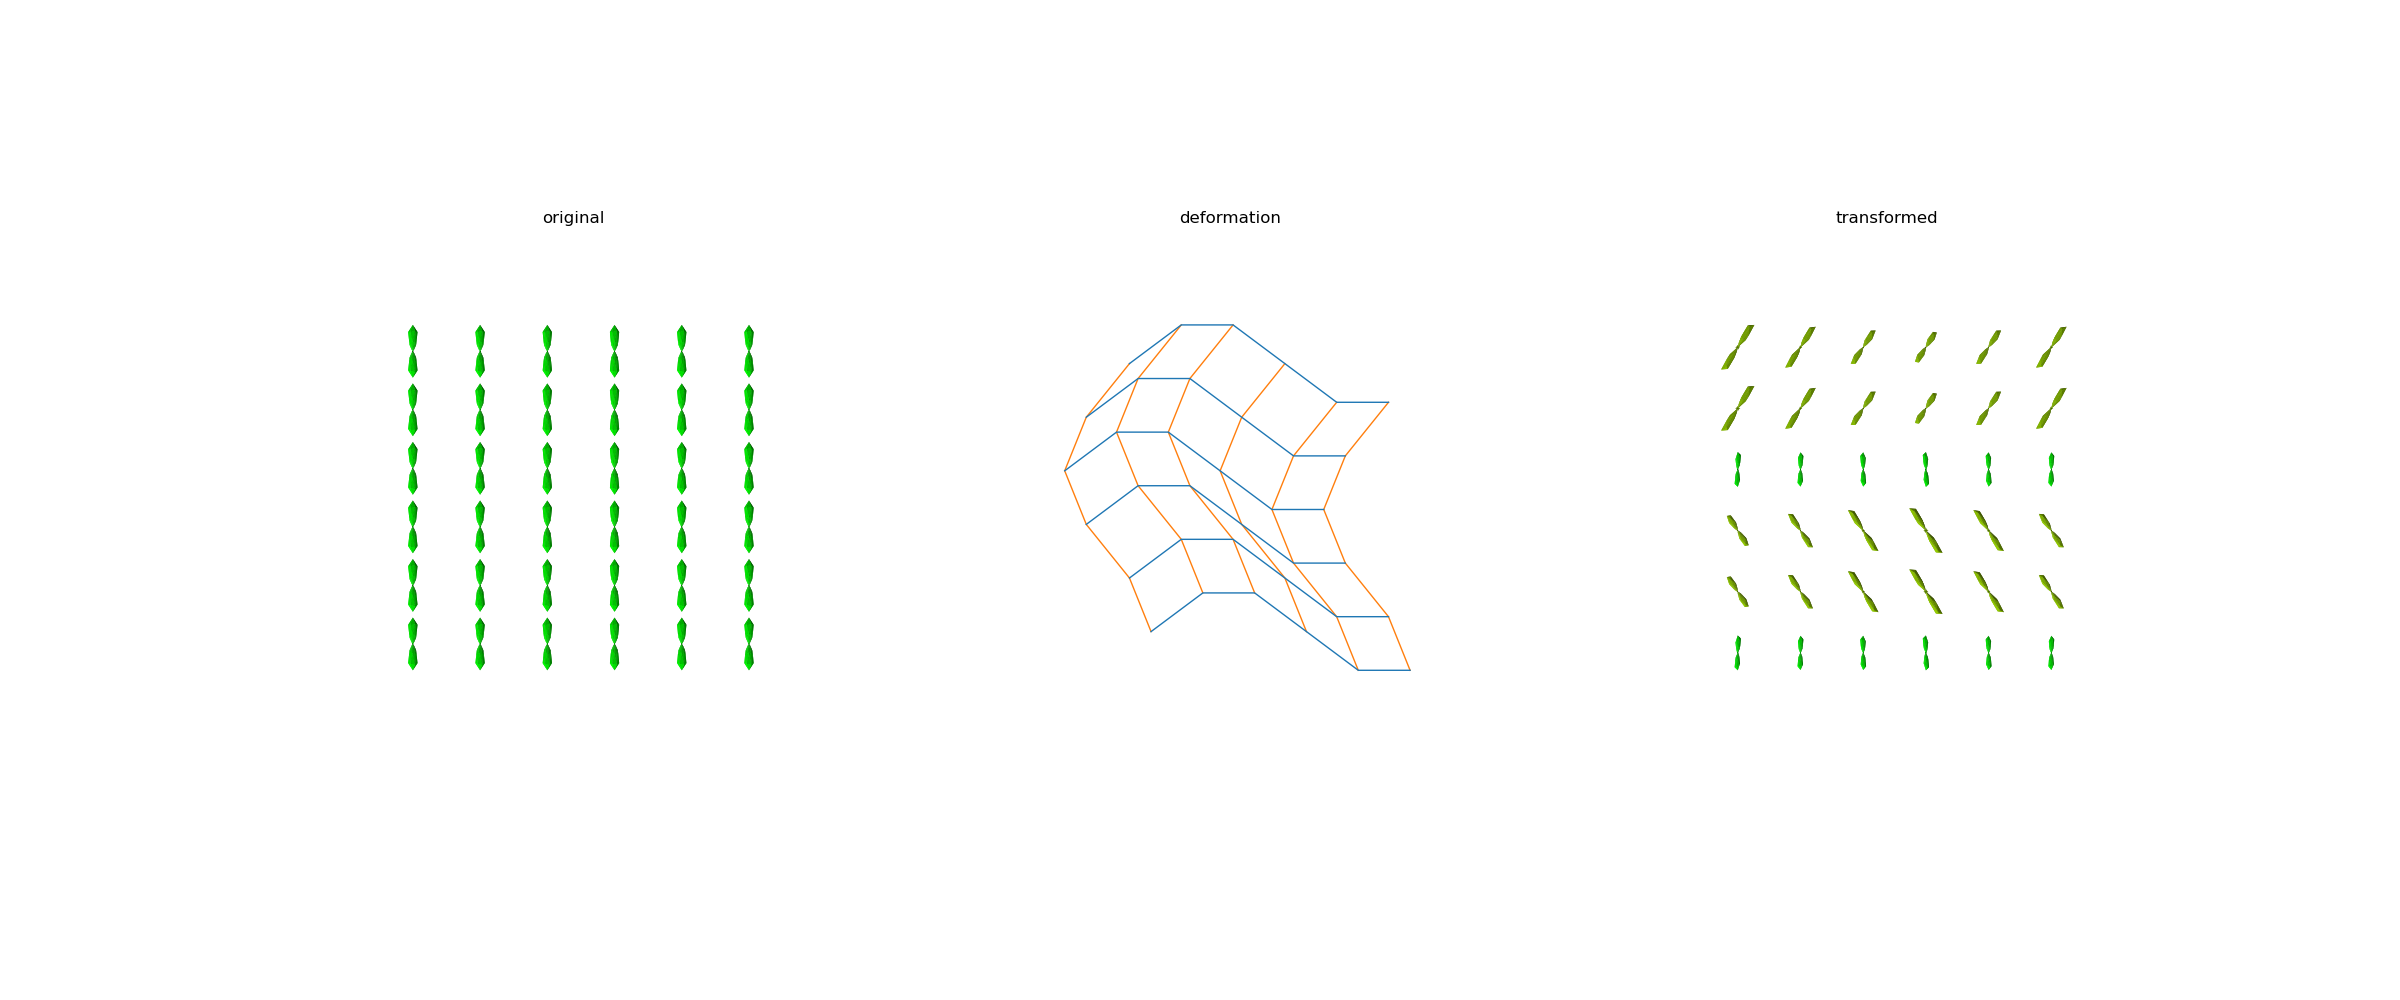

In [50]:
# original ODFs, the deformed grid, and the transformed ODFs side by side
def plot_odf_grid(ax, sh_grid, title):
    sf = np.clip(
        sh_to_sf(sh_grid, sphere, sh_order_max=sh_order_max, basis_type="descoteaux07", legacy=False),
        0,
        None,
    )
    # uniform glyph size so neighboring ODFs do not overlap
    scale = 0.45 / sf.max()
    verts = sphere.vertices

    for i in range(sf.shape[0]):
        for j in range(sf.shape[1]):
            points = verts * (scale * sf[i, j])[:, None]
            color = np.abs(verts[np.argmax(sf[i, j])])  # direction-encoded color from the ODF peak
            ax.plot_trisurf(
                points[:, 0] + i,
                points[:, 1] + j,
                points[:, 2],
                triangles=sphere.faces,
                color=color,
                linewidth=0,
                antialiased=True,
            )

    set_patch_view(ax, sf.shape[:2], title)


plt.close("all")
fig = plt.figure(figsize=(24, 10))
plot_odf_grid(fig.add_subplot(1, 3, 1, projection="3d"), sh_patch, "original")
plot_grid(fig.add_subplot(1, 3, 2, projection="3d"), x_def, y_def, "deformation")
plot_odf_grid(fig.add_subplot(1, 3, 3, projection="3d"), transformed_sh_patch, "transformed")
